In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path01 = '/content/drive/MyDrive/AD561/Assignments/Assignment 4/ftx_dataset.csv'
ftx_dataset = pd.read_csv(file_path01)

# Part 0: Conceptual Warm-Up

A system can appear stable for an extended period of time for a number of reasons, including long-term stable returns and growth, which can boost customer confidence. However, there can be many flaws including opacity and a liquidity mismatch, where there is a disconnect between the information and confidence of the customers and how the system is using the funds. Ultimately, fragile systems maintain a disconnect between customer expectations and the actual use of their funds, meaning that when sentiment shifts and withdrawal demand surges, the underlying liquidity mismatch is exposed and collapse follows rapidly

# Part 1: Case Setup and Key Metric

In [ ]:
ftx_dataset

,balance_type,item,amount_usd_bil,liquid_share_pct,stress_haircut_pct,affiliate_linked_flag,usable_for_withdrawals_pct
0,Asset,Cash_and_stablecoins,1.8,100,0,0,100
1,Asset,Liquid_crypto_BTC_ETH,2.6,85,12,0,80
2,Asset,FTT_and_affiliated_tokens,3.4,15,65,1,10
3,Asset,Loans_to_related_parties,5.1,0,90,1,0
4,Asset,Venture_investments,2.2,5,55,0,0
5,Asset,Real_estate_and_private_assets,0.7,0,50,0,0
6,Asset,Other_crypto_assets,1.6,30,35,0,20
7,Liability,Customer_payables,8.9,0,0,0,0
8,Liability,Secured_borrowing,1.5,0,0,0,0
9,Liability,Other_liabilities,0.8,0,0,0,0


Balance Type: Whether something is an Asset (owned) or a Liability (owed)

Item: The specific Asset or Liability being described

Amount USD Billions (\$): The dollar values in Billions of USD

Liquid Share %: The percentage of that item that can be quickly converted to cash

Stress Haircut %: How much value an Asset would lose in a crisis scenario

Affiliate Linked Flag: A Binary marker indicating if something is tied to Alameda or FTX affiliated entities

Usable of Withdrawals %: What percentage of that item could actually be used to pay back customers in an event of withdrawal demand


In [ ]:
ftx_dataset['usable_normal_bil'] = (ftx_dataset['amount_usd_bil'] * (ftx_dataset['usable_for_withdrawals_pct'] / 100))
ftx_dataset['usable_stressed_bil'] = (ftx_dataset['amount_usd_bil'] * (ftx_dataset['usable_for_withdrawals_pct'] / 100) * (1 - ftx_dataset['stress_haircut_pct'] / 100))

In [ ]:
ftx_dataset

,balance_type,item,amount_usd_bil,liquid_share_pct,stress_haircut_pct,affiliate_linked_flag,usable_for_withdrawals_pct,usable_normal_bil,usable_stressed_bil
0,Asset,Cash_and_stablecoins,1.8,100,0,0,100,1.80,1.8000
1,Asset,Liquid_crypto_BTC_ETH,2.6,85,12,0,80,2.08,1.8304
2,Asset,FTT_and_affiliated_tokens,3.4,15,65,1,10,0.34,0.1190
3,Asset,Loans_to_related_parties,5.1,0,90,1,0,0.00,0.0000
4,Asset,Venture_investments,2.2,5,55,0,0,0.00,0.0000
5,Asset,Real_estate_and_private_assets,0.7,0,50,0,0,0.00,0.0000
6,Asset,Other_crypto_assets,1.6,30,35,0,20,0.32,0.2080
7,Liability,Customer_payables,8.9,0,0,0,0,0.00,0.0000
8,Liability,Secured_borrowing,1.5,0,0,0,0,0.00,0.0000
9,Liability,Other_liabilities,0.8,0,0,0,0,0.00,0.0000


Usable Normal BIL: The dollar value that each asset that could realistically be used to fulfil customer withdrawals under normal market conditions. Calculated by multiplying the asset amount by its usable withdrawal percentage.

Usable Stressed BIL: The same measure as above, but applied under crisis conditions, where an additional stress haircut is applied to reflect the decline in the asset during the market shock, resulting in a lower recoverable amount.

As a result of creating these two variables, we are able to compute the Withdrawal Coverage Ratio. The Withdrawal coverage ratio (WCR) is defined as the total usable assets divided by total customer payables. If the WCR is 1.0 or above, it means that the system can fully cover their withdrawal demand. A WCR below 1.0 indicates insolvency, meaning the system cannot meet its obligations to customers. This metric, computed under both normal and stressed conditions allows us to see how fragile the system is when asset values deteriorate.

I will also be using the coverage gap to explain the dollar shortfall between the total customer payables and the total usable assests. In other words, it shows the amount that FTX would be unable to repay customers if all withdrawals were demanded at once.

In [ ]:
total_usable_normal   = ftx_dataset[ftx_dataset['balance_type'] == 'Asset']['usable_normal_bil'].sum()
total_usable_stressed = ftx_dataset[ftx_dataset['balance_type'] == 'Asset']['usable_stressed_bil'].sum()
customer_payables     = ftx_dataset[ftx_dataset['item'] == 'Customer_payables']['amount_usd_bil'].values[0]

wcr_normal   = total_usable_normal   / customer_payables
wcr_stressed = total_usable_stressed / customer_payables

print("=" * 50)
print("WITHDRAWAL COVERAGE RATIO (WCR)")
print("=" * 50)
print(f"\nTotal Customer Payables:        ${customer_payables:.2f}B")
print(f"Total Usable Assets (Normal):   ${total_usable_normal:.2f}B")
print(f"Total Usable Assets (Stressed): ${total_usable_stressed:.2f}B")
print(f"\nWCR Normal:   {wcr_normal:.4f}  {'✅ Solvent' if wcr_normal >= 1 else '❌ Insolvent'}")
print(f"WCR Stressed: {wcr_stressed:.4f}  {'✅ Solvent' if wcr_stressed >= 1 else '❌ Insolvent'}")

WITHDRAWAL COVERAGE RATIO (WCR)

Total Customer Payables:        $8.90B
Total Usable Assets (Normal):   $4.54B
Total Usable Assets (Stressed): $3.96B

WCR Normal:   0.5101  ❌ Insolvent
WCR Stressed: 0.4447  ❌ Insolvent


In [ ]:
print(f"\nCoverage Gap (Normal):   ${customer_payables - total_usable_normal:.2f}B")
print(f"Coverage Gap (Stressed): ${customer_payables - total_usable_stressed:.2f}B")


Coverage Gap (Normal):   $4.36B
Coverage Gap (Stressed): $4.94B


FTX WCR of 0.51 under normal conditions signals a fragile system, as the firm can only cover roughly half of its \$8.09B in customers payables, with just \$4.5B in usable assets, leaving a \$4.3B gap before any stress is applied. Under the stress conditions, the WCR drops even further to 0.44, with the usable assets falling to \$3.96B and the coverage gap increased to \$4.94B. Overall, the system looks fragile. The raw data does not immediately reveal how FTX's total asset figure appears at face value. Assets like FTT tokens (\$3.41B) and loans to related parties (\$5.10B) together account for over \$8.5B on the balance sheet, yet contribute virtually nothing to withdrawal coverage due to their zero usability ratings and affiiliate linkages. Once the constraints are applied, the asset base collapses quickly. The system is not borderline insolvent, it is structurally insolvent by a large margin, and this fragility exists entirely independent of any external shock.

# Part 2: Shock Scenario

In [ ]:
# ── Shock Parameters ──────────────────────────────────────────
withdrawal_shock_pct      = 0.30
customer_payables_shocked = customer_payables * (1 + withdrawal_shock_pct)

# ── Recompute WCR Under Shock ─────────────────────────────────
wcr_normal_shocked   = total_usable_normal   / customer_payables_shocked
wcr_stressed_shocked = total_usable_stressed / customer_payables_shocked

# ── Coverage Gaps ─────────────────────────────────────────────
gap_normal_pre    = customer_payables         - total_usable_normal
gap_normal_post   = customer_payables_shocked - total_usable_normal
gap_stressed_pre  = customer_payables         - total_usable_stressed
gap_stressed_post = customer_payables_shocked - total_usable_stressed

# ── Output ────────────────────────────────────────────────────
print("=" * 55)
print("PART 2 – SHOCK SCENARIO: 30% WITHDRAWAL INCREASE")
print("=" * 55)

print(f"\n{'':30} {'Pre-Shock':>10} {'Post-Shock':>10}")
print("-" * 55)
print(f"{'Customer Payables ($B)':<30} {customer_payables:>10.2f} {customer_payables_shocked:>10.2f}")
print(f"{'WCR (Normal)':<30} {wcr_normal:>10.4f} {wcr_normal_shocked:>10.4f}")
print(f"{'WCR (Stressed)':<30} {wcr_stressed:>10.4f} {wcr_stressed_shocked:>10.4f}")
print(f"{'Coverage Gap Normal ($B)':<30} {gap_normal_pre:>10.2f} {gap_normal_post:>10.2f}")
print(f"{'Coverage Gap Stressed ($B)':<30} {gap_stressed_pre:>10.2f} {gap_stressed_post:>10.2f}")

print(f"\n{'Solvency Status':<30} {'Pre-Shock':>10} {'Post-Shock':>10}")
print("-" * 55)
print(f"{'WCR (Normal)':<30} {'❌ Insolvent':>10} {'❌ Insolvent':>10}")
print(f"{'WCR (Stressed)':<30} {'❌ Insolvent':>10} {'❌ Insolvent':>10}")

PART 2 – SHOCK SCENARIO: 30% WITHDRAWAL INCREASE

                                Pre-Shock Post-Shock
-------------------------------------------------------
Customer Payables ($B)               8.90      11.57
WCR (Normal)                       0.5101     0.3924
WCR (Stressed)                     0.4447     0.3420
Coverage Gap Normal ($B)             4.36       7.03
Coverage Gap Stressed ($B)           4.94       7.61

Solvency Status                 Pre-Shock Post-Shock
-------------------------------------------------------
WCR (Normal)                   ❌ Insolvent ❌ Insolvent
WCR (Stressed)                 ❌ Insolvent ❌ Insolvent


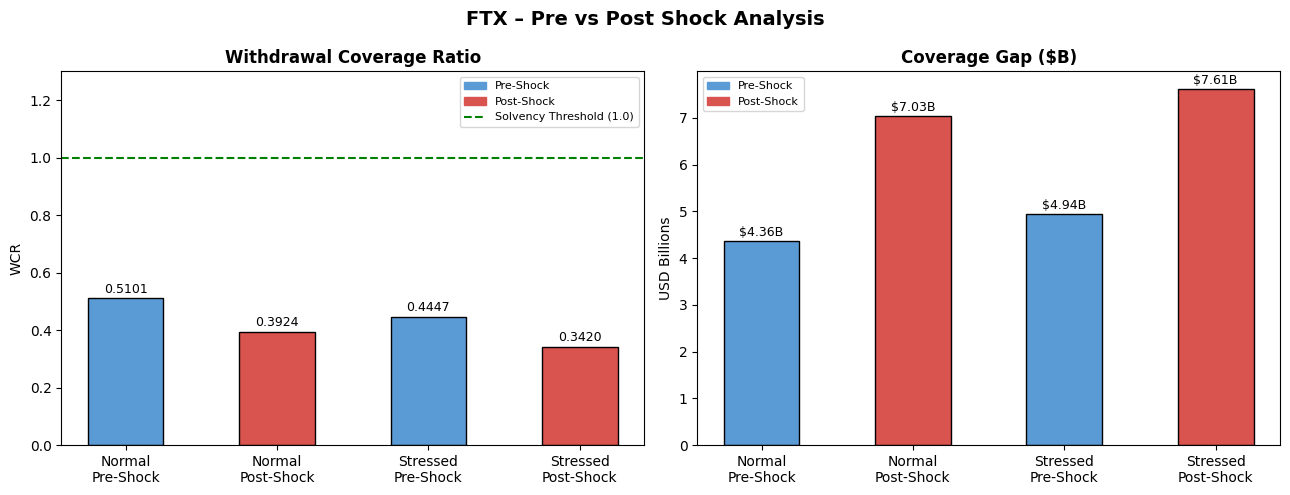

In [ ]:
# ── Shared Data ───────────────────────────────────────────────
labels   = ['Normal\nPre-Shock', 'Normal\nPost-Shock', 'Stressed\nPre-Shock', 'Stressed\nPost-Shock']
wcr_vals = [wcr_normal, wcr_normal_shocked, wcr_stressed, wcr_stressed_shocked]

# ── Shared Color Scheme ───────────────────────────────────────
pre_color  = '#5b9bd5'  # Blue – Pre-Shock
post_color = '#d9534f'  # Red  – Post-Shock
bar_colors = [pre_color, post_color, pre_color, post_color]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1 – WCR Comparison ──────────────────────────────────
ax1.bar(labels, wcr_vals, color=bar_colors, edgecolor='black', width=0.5)
ax1.axhline(y=1.0, color='green', linestyle='--', linewidth=1.5, label='Solvency Threshold (1.0)')
for bar, val in zip(ax1.patches, wcr_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax1.set_title('Withdrawal Coverage Ratio', fontsize=12, fontweight='bold')
ax1.set_ylabel('WCR')
ax1.set_ylim(0, 1.3)

pre_patch  = mpatches.Patch(color=pre_color,  label='Pre-Shock')
post_patch = mpatches.Patch(color=post_color, label='Post-Shock')
ax1.legend(handles=[pre_patch, post_patch, plt.Line2D([0], [0], color='green', linestyle='--', label='Solvency Threshold (1.0)')], fontsize=8)

# ── Panel 2 – Coverage Gap Comparison ────────────────────────
gap_labels = ['Normal\nPre-Shock', 'Normal\nPost-Shock', 'Stressed\nPre-Shock', 'Stressed\nPost-Shock']
gap_vals   = [gap_normal_pre, gap_normal_post, gap_stressed_pre, gap_stressed_post]
ax2.bar(gap_labels, gap_vals, color=bar_colors, edgecolor='black', width=0.5)
for bar, val in zip(ax2.patches, gap_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'${val:.2f}B', ha='center', va='bottom', fontsize=9)
ax2.set_title('Coverage Gap ($B)', fontsize=12, fontweight='bold')
ax2.set_ylabel('USD Billions')
ax2.legend(handles=[pre_patch, post_patch], fontsize=8)

fig.suptitle('FTX – Pre vs Post Shock Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The 30% withdrawal surge shock shows that the FTX system deteriorates rapidly rather than gradually. The WCR under normal conditions falls from 0.51 5o 0.39, which the stressed WCR drops from 0.44 to 0.34, showing a meaningful decline across both measures. More notably, the coverage gap widens from \$4.36B to \$7.03B under normal conditions, and from \$4.94B to \$7.61B under stress, showing a deterioration of over \$2.6B in each case from a single shock.

The variable that mattered the most was the customer payables. Since usable assets are fixed and cannot be quickly mobilized in response to surging demand, any increase in withdrawl pressure directly and proportionally widens the coverage gap. This exposes a critical strucutural weakness, the asset side of the balance sheet has no flexibility to respond to demand-side shocks.

The behavior is largely linear within this single shock scenario, as a 30% increase in payables produces a near-proportional decline in WCR. However, I believe that more important non-linear risk occurs under the surface... if a withdrawal surge triggers a loss of confidence, it could cause a cascading run where demand far exceeds 30%, this could rapidly push the WCR towards zero. FTX was already insolvent before the shock and the surge would accelerate the inveitable collapse.

# Part 3

## Stress Map

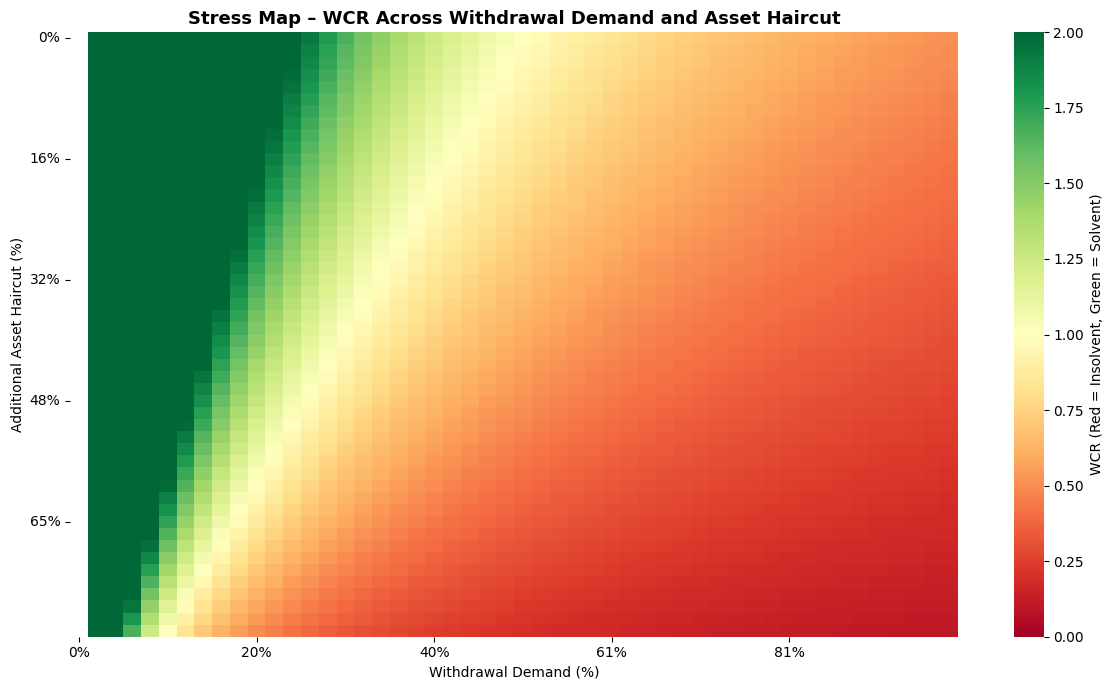

In [ ]:

# ── Grid Parameters ───────────────────────────────────────────
withdrawal_range = np.linspace(0.0, 1.0, 50)   # 0% to 100% withdrawal demand
haircut_range    = np.linspace(0.0, 0.8, 50)   # 0% to 80% additional haircut

# ── WCR Function ──────────────────────────────────────────────
def compute_wcr(withdrawal_pct, additional_haircut):
    adjusted_usable = total_usable_normal * (1 - additional_haircut)
    effective_payables = customer_payables * withdrawal_pct
    if effective_payables == 0:
        return np.nan
    return adjusted_usable / effective_payables

# ── Evaluate Across Grid ──────────────────────────────────────
wcr_grid = np.zeros((len(haircut_range), len(withdrawal_range)))

for i, haircut in enumerate(haircut_range):
    for j, withdrawal in enumerate(withdrawal_range):
        wcr_grid[i, j] = compute_wcr(withdrawal, haircut)

# ── Plot Heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    wcr_grid,
    ax=ax,
    cmap='RdYlGn',
    center=1.0,
    vmin=0,
    vmax=2,
    xticklabels=10,
    yticklabels=10,
    cbar_kws={'label': 'WCR (Red = Insolvent, Green = Solvent)'}
)

ax.set_title('Stress Map – WCR Across Withdrawal Demand and Asset Haircut', fontsize=13, fontweight='bold')
ax.set_xlabel('Withdrawal Demand (%)')
ax.set_ylabel('Additional Asset Haircut (%)')

# ── Format Axis Labels as Percentages ────────────────────────
x_ticks = [f'{int(v*100)}%' for v in withdrawal_range[::10]]
y_ticks = [f'{int(v*100)}%' for v in haircut_range[::10]]
ax.set_xticklabels(x_ticks)
ax.set_yticklabels(y_ticks, rotation=0)

plt.tight_layout()
plt.show()

The stress map reveals that the FTX's systems fails across the vast majority on conditions simulated. The green area - which represents solvency - is confined to a relatively small, narrow band across the left hand side. We see it widen slightly as the withdrawal demand increases. It remains green where the withdrawal demand stays below approximately 20%, and the asset haircuts are minimal.

The most notable nonlinear observation occurs near the 20% withdrawal threshold. Rather than a gradual transition, there is a sharp boundary where the system crosses from marginally solvent to deeply insolvent, within a very narrow range of withdrawal demands. This is very telling of a confidence-driven run dynamic... once withdrawals surpass a critical threshold, the system does not slowly degrade, rather it collpases.

The withdrawal demand is the clearly the dominant varaible. As we move horizontally across the map, the color transitions from green to red very rapidly and consistently across all haircit levels. This confirms that rising withdrawal demand is the primary driver of the collapse. The asset haircut, while it does contribute to the deterioration in a more secondary role, even at 0% haircit, the system becomes insolvent once withdrawal demand exceeds approximately 35%.

I was surprised that the danger zone for FTX was not just hypothetical, it was actually operating close to it at all times. This meant that even a modest and coordinated withdrawal demand was enough to trigger a collapse of the system under almst any market condition.

## Monte Carlo Simulation

MONTE CARLO SIMULATION RESULTS

Total Simulations:       10,000
Failed Scenarios:        7,743
Failure Probability:     77.43%
Mean WCR:                0.7843
Median WCR:              0.5626
WCR 5th Percentile:      0.1837
WCR 95th Percentile:     2.2272


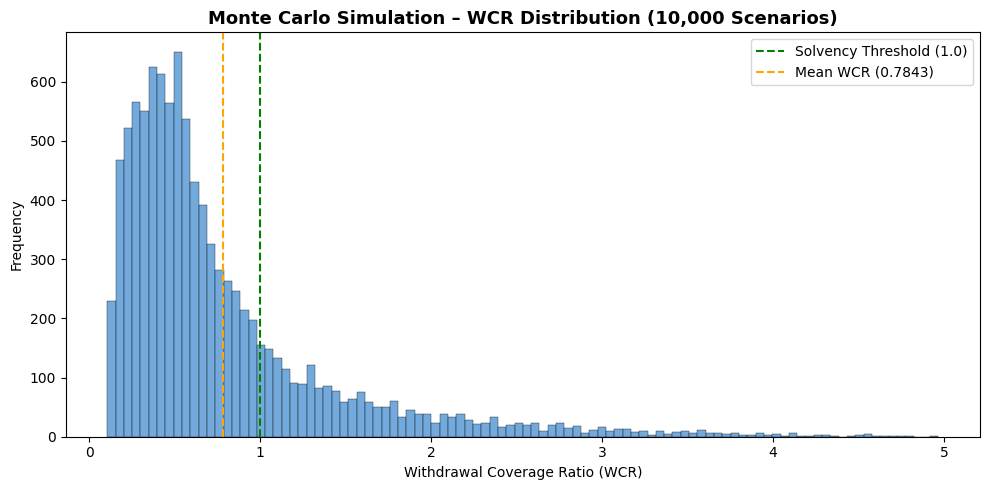

In [ ]:
np.random.seed(42)
n_simulations = 10_000

# ── Uncertain Variables ───────────────────────────────────────
sim_withdrawal = np.random.uniform(0.1, 1.0,  n_simulations)  # 10% to 100% withdrawal demand
sim_haircut    = np.random.uniform(0.0, 0.8,  n_simulations)  # 0%  to 80%  asset haircut

# ── Compute WCR For Each Simulation ──────────────────────────
sim_usable     = total_usable_normal * (1 - sim_haircut)
sim_payables   = customer_payables   * sim_withdrawal
sim_wcr        = sim_usable / sim_payables

# ── Failure Definition ────────────────────────────────────────
sim_failed         = sim_wcr < 1.0
failure_probability = sim_failed.mean()

# ── Output ────────────────────────────────────────────────────
print("=" * 50)
print("MONTE CARLO SIMULATION RESULTS")
print("=" * 50)
print(f"\nTotal Simulations:       {n_simulations:,}")
print(f"Failed Scenarios:        {sim_failed.sum():,}")
print(f"Failure Probability:     {failure_probability:.2%}")
print(f"Mean WCR:                {sim_wcr.mean():.4f}")
print(f"Median WCR:              {np.median(sim_wcr):.4f}")
print(f"WCR 5th Percentile:      {np.percentile(sim_wcr, 5):.4f}")
print(f"WCR 95th Percentile:     {np.percentile(sim_wcr, 95):.4f}")

# ── Distribution Plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sim_wcr, bins=100, color='#5b9bd5', edgecolor='black', linewidth=0.3, alpha=0.85)
ax.axvline(x=1.0,            color='green', linestyle='--', linewidth=1.5, label='Solvency Threshold (1.0)')
ax.axvline(x=sim_wcr.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean WCR ({sim_wcr.mean():.4f})')

ax.set_title('Monte Carlo Simulation – WCR Distribution (10,000 Scenarios)', fontsize=13, fontweight='bold')
ax.set_xlabel('Withdrawal Coverage Ratio (WCR)')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

Over the 10,000 simulations scenarios ran, FTX failed in 7,743 of them, representing a failure probability of 77.43%. This means the system collapses in roughly 3 out of every 4 possible situations, which is not a systems operating near the fragility, but rather one that is structurally predisposed to failure under almost any realistic set of conditions.

The system usuaally collapses... survival is more likely an exception rather than a rule. The mean WCR of 0.78 sits well below the solvency thresholdhold of 1.0, and the median of 0.56 suggests that in a typical scenario, FTX can only cover a little more than half of its customer obligations.

Failure of the systems is driven by common cases. The histogram shows that it is heavily concentrated below the solvency threshold, meaning insolvency is the most frequent outcome across the distribution - not a tail risk reserved for catastrophic conditions. The 5th percentile WCR pf 0.18, represents the most severe outcomes, but even the median scenario results in deep insolvency.

The right tail of the distribution, where the WCR exceeds 1.0, represents cases where customers demand very little of their funds back, not cases where FTX has sufficient assets. FTX's apparent stability was entirely dependent on customer inaction, meaning the fragility was not hidden deep within stress scenarios, but present in ordinary ones, concealed only by the assumption that customers would never simulatneously demand their money back.



# Part 4: Breaking Point Analysis

PART 4 – BREAKING POINT ANALYSIS

Scenario                        Breaking Point
-------------------------------------------------------
Normal Conditions                      51.05%
Stressed Conditions                    44.50%

Current Withdrawal Demand (Base): 100%
Normal  Breaking Point:           51.05%
Stressed Breaking Point:          44.50%

Excess Demand Beyond Breaking Point (Normal):   48.95%
Excess Demand Beyond Breaking Point (Stressed): 55.50%


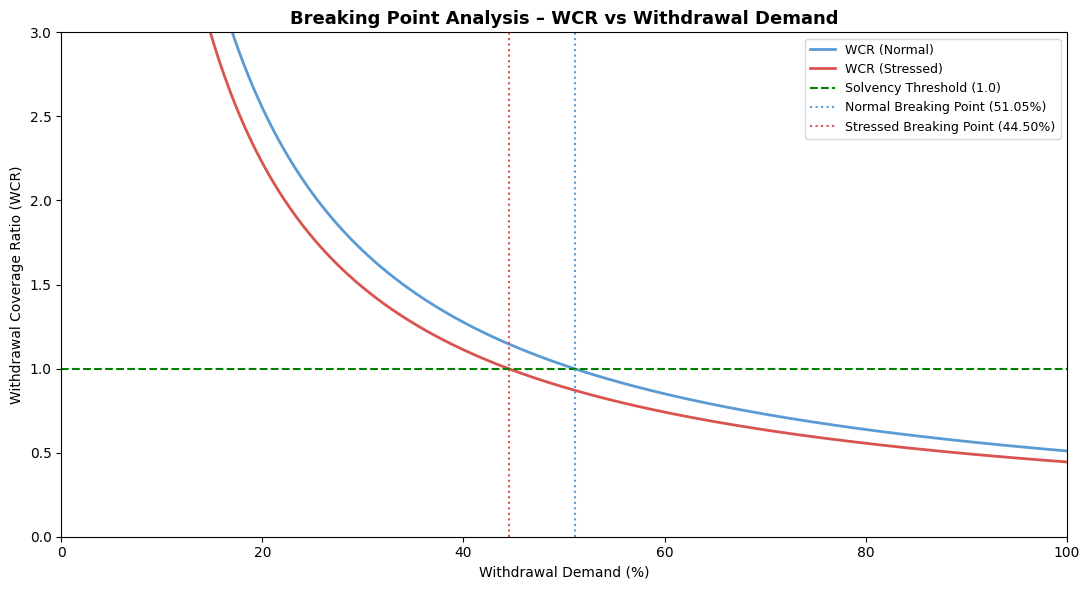

In [ ]:
# ── Variable Range ────────────────────────────────────────────
withdrawal_range = np.linspace(0.01, 1.0, 1000)  # 1% to 100% withdrawal demand

# ── Compute WCR Across Range ──────────────────────────────────
wcr_values        = total_usable_normal   / (customer_payables * withdrawal_range)
wcr_values_stress = total_usable_stressed / (customer_payables * withdrawal_range)

# ── Identify Breaking Points ──────────────────────────────────
breaking_point_normal  = withdrawal_range[np.argmax(wcr_values        < 1.0)]
breaking_point_stress  = withdrawal_range[np.argmax(wcr_values_stress < 1.0)]

# ── Output Table ──────────────────────────────────────────────
print("=" * 55)
print("PART 4 – BREAKING POINT ANALYSIS")
print("=" * 55)
print(f"\n{'Scenario':<30} {'Breaking Point':>15}")
print("-" * 55)
print(f"{'Normal Conditions':<30} {breaking_point_normal:>14.2%}")
print(f"{'Stressed Conditions':<30} {breaking_point_stress:>14.2%}")
print(f"\nCurrent Withdrawal Demand (Base): 100%")
print(f"Normal  Breaking Point:           {breaking_point_normal:.2%}")
print(f"Stressed Breaking Point:          {breaking_point_stress:.2%}")
print(f"\nExcess Demand Beyond Breaking Point (Normal):   {1.0 - breaking_point_normal:.2%}")
print(f"Excess Demand Beyond Breaking Point (Stressed): {1.0 - breaking_point_stress:.2%}")

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(withdrawal_range * 100, wcr_values,        color='#5b9bd5', linewidth=2,    label='WCR (Normal)')
ax.plot(withdrawal_range * 100, wcr_values_stress, color='#d9534f', linewidth=2,    label='WCR (Stressed)')
ax.axhline(y=1.0,                                  color='green',   linestyle='--', linewidth=1.5, label='Solvency Threshold (1.0)')
ax.axvline(x=breaking_point_normal  * 100,         color='#5b9bd5', linestyle=':',  linewidth=1.5, label=f'Normal Breaking Point ({breaking_point_normal:.2%})')
ax.axvline(x=breaking_point_stress  * 100,         color='#d9534f', linestyle=':',  linewidth=1.5, label=f'Stressed Breaking Point ({breaking_point_stress:.2%})')

ax.set_title('Breaking Point Analysis – WCR vs Withdrawal Demand', fontsize=13, fontweight='bold')
ax.set_xlabel('Withdrawal Demand (%)')
ax.set_ylabel('Withdrawal Coverage Ratio (WCR)')
ax.set_ylim(0, 3)
ax.set_xlim(0, 100)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

The breaking point under normal conditions occurs at a withdrawal demand of 51.05%, meaning FTX becomes insolvent once just over half of its customers demand their funds simultaneously. Under stressed conditions, this falls further to 44.50%, as the additional asset haircut reduces the usable asset base and pushes the system into insolvency even sooner.

The curver declines steeply at low withdrawal levels and flattens as demand approaches 100%, which is characteristic of a hyperbolic relationship rather than a linear one. This means the system is most sensitive to early increases in withdrawal demand - small increases near the breaking point produce disproportionately large drops in the WCR, indicating abrupt rather than gradual failure.

This is perhaps the most concerning finding within the analysis. FTX's baseline withdrawal demand is effectively 1005 in a run scenario, meaning it operates at nearly double its breaking point at all times. Even under normal conditions, the system would need customers to collectively demand less than half of their funds to remain solvent. There is no buffer, no margin of safety amd no realitic path to solvency under genuine withdrawal pressure, the breaking point is not a distant boundary, but rather one that is crossed the moment customer confidence begins to erode.

# Final Section: Reflection

The biggest source of fragility in the FTX case was the disconnect betweeen what the balance sheet appeared to show and what they actually had available to meet customer obligations. On the surface, FTX held roughly \$17 billion in total assets - a figure that could reasonably suggest a well-capitalized institution. However, once usability constraints, stress haircuts and affiliate linkages were applued, that figure collapsed to just \$4.54 billion under normal conditions, and \$3.96 billion under stress. The largest individual assets - \$5.10 billion in loans to related parties and \$3.41 billion in FTT tokens - contributed virtually nothing to withdrawal coverage, yet dominated the balance sheet.

Before running this analysis, the system would not have appeared immediatelty insolvent. The raw data presents a large, diversified asset base across seven categories, which creates a superficial impression of financial depth. It is only one the fragility metrics are constructed and the usability constraints are applied, that we begin to see the true picture.

What changed across the multiple scenarios was the confirmation that this is not just a borderline case. The stress map showsed that solvency required withdrawal demand to stay below 20%, which is an unrealistically low threshold. The Monte Carlo simulation returned a 77.43% failure probability across the 10,000 simulations. The breaking point analysis revealed that FTX was operatings nearly double its solvency threshold at all times. Taken together, these findings show that FTX's stability was never real - it was a function of customer inaction, sustained by opacity and unrealistic confidence.

If for some reason, the US were to find itself governed by a Dutch-born, New Zealand-raised president... there is no way I would pardon Sam Bankman-Fried. There are a few main reasons as to why I came to this conclusion. Firstly, based on my brief research, there were over 1 million people impacted by his fraud, with losses of over \$8 billion stolen from FTX customers and \$1.7 billion lost by FTX investors. If he were to be pardoned, this effectively would excuse his actions and ignore the suffering and loses faced by those involved. Secondly, Bankman-Fried deliberately concealed the liquidity mismatch from customers and regulators for many years. This was not due to negligence or poor judgement, this was intentional fraud and therefore should be punishable. Finally, I believe that if he were to be pardoned then this would severly weaken the deterrent effect of financial regulations and perhaps open the door for further fraud to be seen as excusable. If the US wants to build stronger and more robust legislation and rules around financial acitivity, then they must remain firm in their prosecution of indivduals such as Bankman-Fried.